# UDFPS COE 스택 광학 구조 최적화
## 물리 정보 기반 AI 설계 플랫폼 개발
### Phase 1 중간 보고  |  SDI-2026-OPT-PINN-001


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
print('준비 완료')


준비 완료


## 1. 핵심 문제
- OLED UDFPS에서 AR 코팅 위상 왜곡 + BM 회절 → PSF 비대칭
- 기존 LightTools: 위상 정보 처리 불가 → 재현/최적화 불가능
- theta=30도 입사각에서 지문위치오차 10~30um 발생


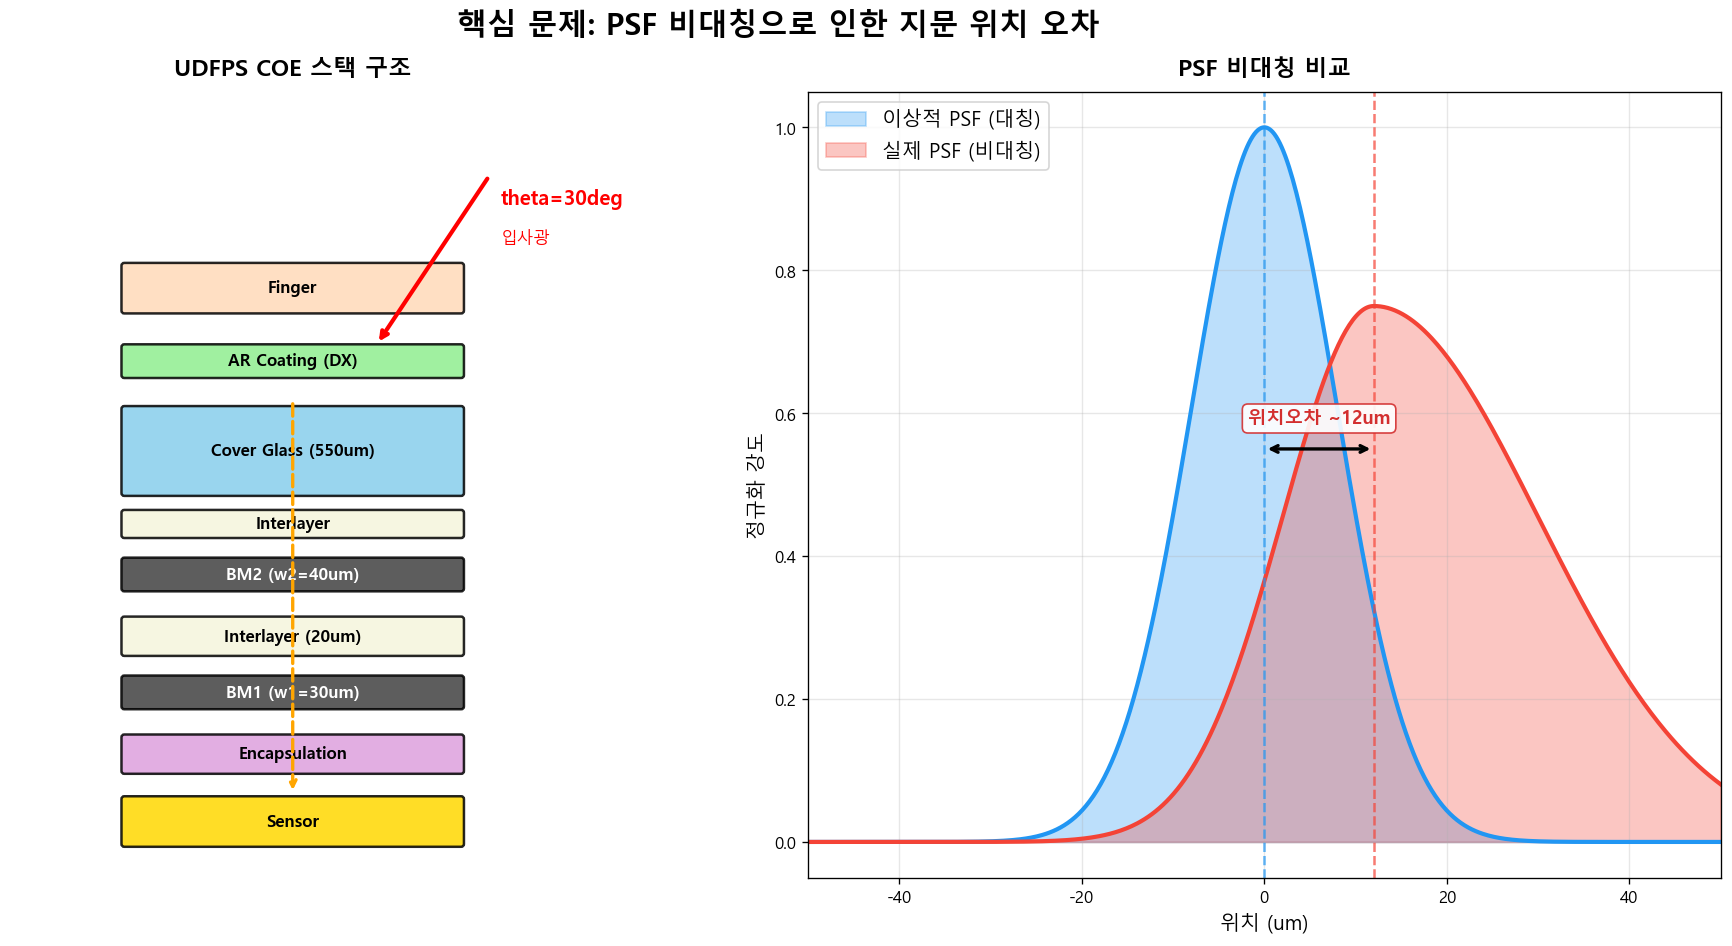

생성 완료: 발표_문제정의.png


In [2]:
import matplotlib.patches as patches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('핵심 문제: PSF 비대칭으로 인한 지문 위치 오차', fontsize=18, fontweight='bold', y=0.98)

# Left: UDFPS COE 스택 구조 (아래→위)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 14)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('UDFPS COE 스택 구조', fontsize=14, fontweight='bold', pad=10)

# (이름, y중심, 색상, 높이)
layers = [
    ('Sensor',              1.0, '#FFD700', 0.8),
    ('Encapsulation',       2.2, '#DDA0DD', 0.6),
    ('BM1 (w1=30um)',       3.3, '#404040', 0.5),
    ('Interlayer (20um)',   4.3, '#F5F5DC', 0.6),
    ('BM2 (w2=40um)',       5.4, '#404040', 0.5),
    ('Interlayer',          6.3, '#F5F5DC', 0.4),
    ('Cover Glass (550um)', 7.6, '#87CEEB', 1.5),
    ('AR Coating (DX)',     9.2, '#90EE90', 0.5),
    ('Finger',             10.5, '#FFDAB9', 0.8),
]

for name, y_center, color, height in layers:
    rect = patches.FancyBboxPatch((2, y_center - height/2), 6, height,
                                   boxstyle='round,pad=0.05',
                                   facecolor=color, edgecolor='black', linewidth=1.5,
                                   alpha=0.85)
    ax1.add_patch(rect)
    tc = 'white' if color == '#404040' else 'black'
    ax1.text(5, y_center, name, ha='center', va='center',
             fontsize=10, fontweight='bold', color=tc)

# 광 경로 화살표 (위에서 아래로)
ax1.annotate('', xy=(6.5, 9.5), xytext=(8.5, 12.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax1.text(8.7, 12.0, 'theta=30deg', fontsize=12, color='red', fontweight='bold')
ax1.text(8.7, 11.3, '입사광', fontsize=10, color='red')

# 내부 전파 화살표
ax1.annotate('', xy=(5, 1.5), xytext=(5, 8.5),
             arrowprops=dict(arrowstyle='->', color='orange', lw=2, ls='--'))

# Right: PSF comparison
ax2.set_title('PSF 비대칭 비교', fontsize=14, fontweight='bold', pad=10)
x = np.linspace(-50, 50, 500)
psf_ideal = np.exp(-x**2 / (2 * 8**2))
psf_ideal = psf_ideal / psf_ideal.max()
shift = 12
sigma_l, sigma_r = 10, 18
psf_actual = np.where(x < shift,
                      np.exp(-(x-shift)**2/(2*sigma_l**2)),
                      np.exp(-(x-shift)**2/(2*sigma_r**2)))
psf_actual = psf_actual / psf_actual.max() * 0.75

ax2.fill_between(x, psf_ideal, alpha=0.3, color='#2196F3', label='이상적 PSF (대칭)')
ax2.plot(x, psf_ideal, color='#2196F3', lw=2.5)
ax2.fill_between(x, psf_actual, alpha=0.3, color='#F44336', label='실제 PSF (비대칭)')
ax2.plot(x, psf_actual, color='#F44336', lw=2.5)
ax2.axvline(0, color='#2196F3', ls='--', alpha=0.7, lw=1.5)
ax2.axvline(shift, color='#F44336', ls='--', alpha=0.7, lw=1.5)
ax2.annotate('', xy=(shift, 0.55), xytext=(0, 0.55),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(shift/2, 0.58, f'위치오차 ~{shift}um', ha='center', va='bottom',
         fontsize=11, fontweight='bold', color='#D32F2F',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#D32F2F', alpha=0.9))
ax2.set_xlabel('위치 (um)', fontsize=12)
ax2.set_ylabel('정규화 강도', fontsize=12)
ax2.legend(fontsize=12, loc='upper left')
ax2.set_xlim(-50, 50)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('발표_문제정의.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('생성 완료: 발표_문제정의.png')


## 2. 해결 방안: 6-Layer AI 설계 플랫폼


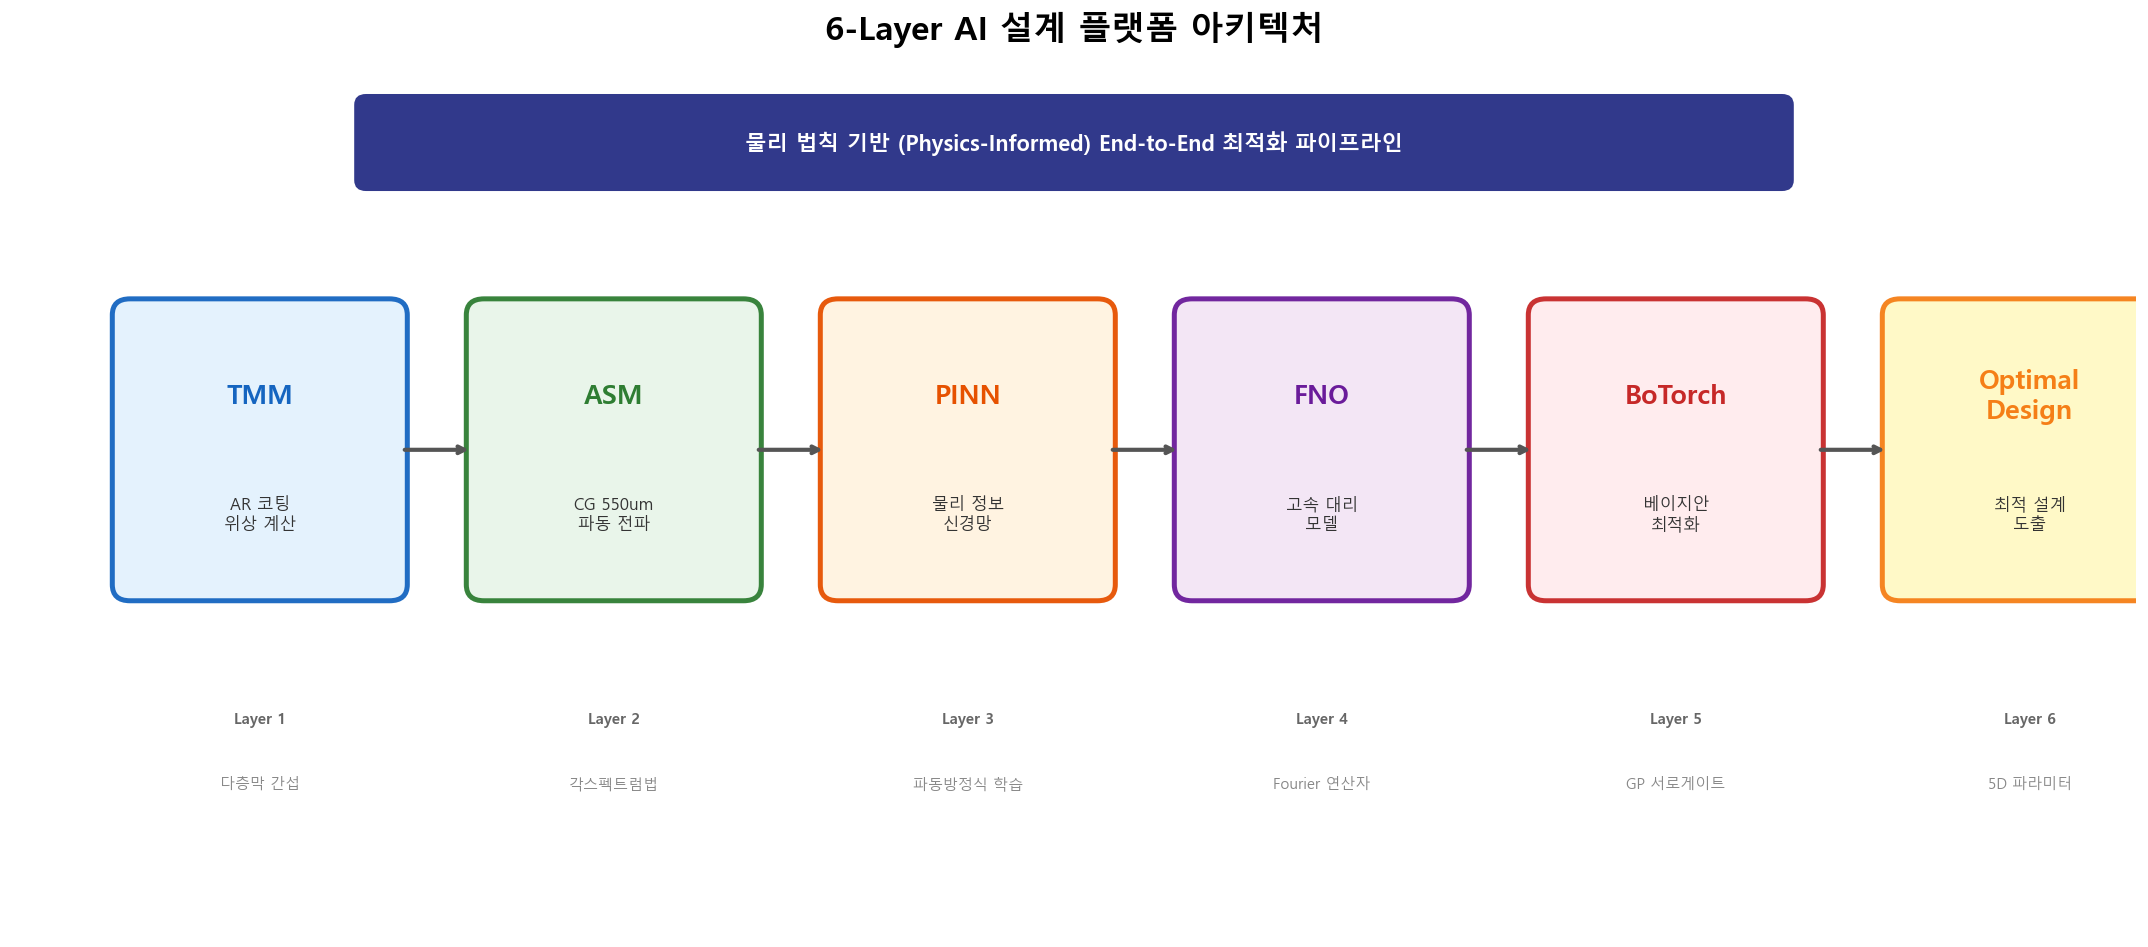

저장 완료: 발표_플랫폼구조.png


In [3]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(18, 8))
ax.set_xlim(0, 18)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('6-Layer AI 설계 플랫폼 아키텍처', fontsize=20, fontweight='bold', pad=20)

modules = [
    {'name': 'TMM', 'desc': 'AR 코팅\n위상 계산', 'x': 1.0, 'color': '#E3F2FD', 'edge': '#1565C0'},
    {'name': 'ASM', 'desc': 'CG 550um\n파동 전파', 'x': 4.0, 'color': '#E8F5E9', 'edge': '#2E7D32'},
    {'name': 'PINN', 'desc': '물리 정보\n신경망', 'x': 7.0, 'color': '#FFF3E0', 'edge': '#E65100'},
    {'name': 'FNO', 'desc': '고속 대리\n모델', 'x': 10.0, 'color': '#F3E5F5', 'edge': '#6A1B9A'},
    {'name': 'BoTorch', 'desc': '베이지안\n최적화', 'x': 13.0, 'color': '#FFEBEE', 'edge': '#C62828'},
    {'name': 'Optimal\nDesign', 'desc': '최적 설계\n도출', 'x': 16.0, 'color': '#FFF9C4', 'edge': '#F57F17'},
]

box_w = 2.2
box_h = 2.5
y_center = 4.5

for i, m in enumerate(modules):
    # Main box
    rect = patches.FancyBboxPatch((m['x'], y_center - box_h/2), box_w, box_h,
                                   boxstyle='round,pad=0.15',
                                   facecolor=m['color'], edgecolor=m['edge'],
                                   linewidth=3, alpha=0.95)
    ax.add_patch(rect)
    ax.text(m['x'] + box_w/2, y_center + 0.5, m['name'],
            ha='center', va='center', fontsize=16, fontweight='bold', color=m['edge'])
    ax.text(m['x'] + box_w/2, y_center - 0.6, m['desc'],
            ha='center', va='center', fontsize=10, color='#333333')

    # Arrow to next box
    if i < len(modules) - 1:
        next_x = modules[i + 1]['x']
        ax.annotate('', xy=(next_x - 0.1, y_center), xytext=(m['x'] + box_w + 0.1, y_center),
                     arrowprops=dict(arrowstyle='->', color='#555555', lw=2.5,
                                     connectionstyle='arc3,rad=0'))

# Bottom labels with phase info
phase_labels = [
    (2.1, 'Layer 1', '다층막 간섭'),
    (5.1, 'Layer 2', '각스펙트럼법'),
    (8.1, 'Layer 3', '파동방정식 학습'),
    (11.1, 'Layer 4', 'Fourier 연산자'),
    (14.1, 'Layer 5', 'GP 서로게이트'),
    (17.1, 'Layer 6', '5D 파라미터'),
]

for x, label, detail in phase_labels:
    ax.text(x, 2.0, label, ha='center', va='center', fontsize=9,
            fontweight='bold', color='#666666')
    ax.text(x, 1.4, detail, ha='center', va='center', fontsize=9, color='#888888')

# Top banner
banner = patches.FancyBboxPatch((3, 7.0), 12, 0.7,
                                 boxstyle='round,pad=0.1',
                                 facecolor='#1A237E', edgecolor='none', alpha=0.9)
ax.add_patch(banner)
ax.text(9, 7.35, '물리 법칙 기반 (Physics-Informed) End-to-End 최적화 파이프라인',
        ha='center', va='center', fontsize=13, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('발표_플랫폼구조.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('저장 완료: 발표_플랫폼구조.png')


## 3. Phase 1 핵심 성과


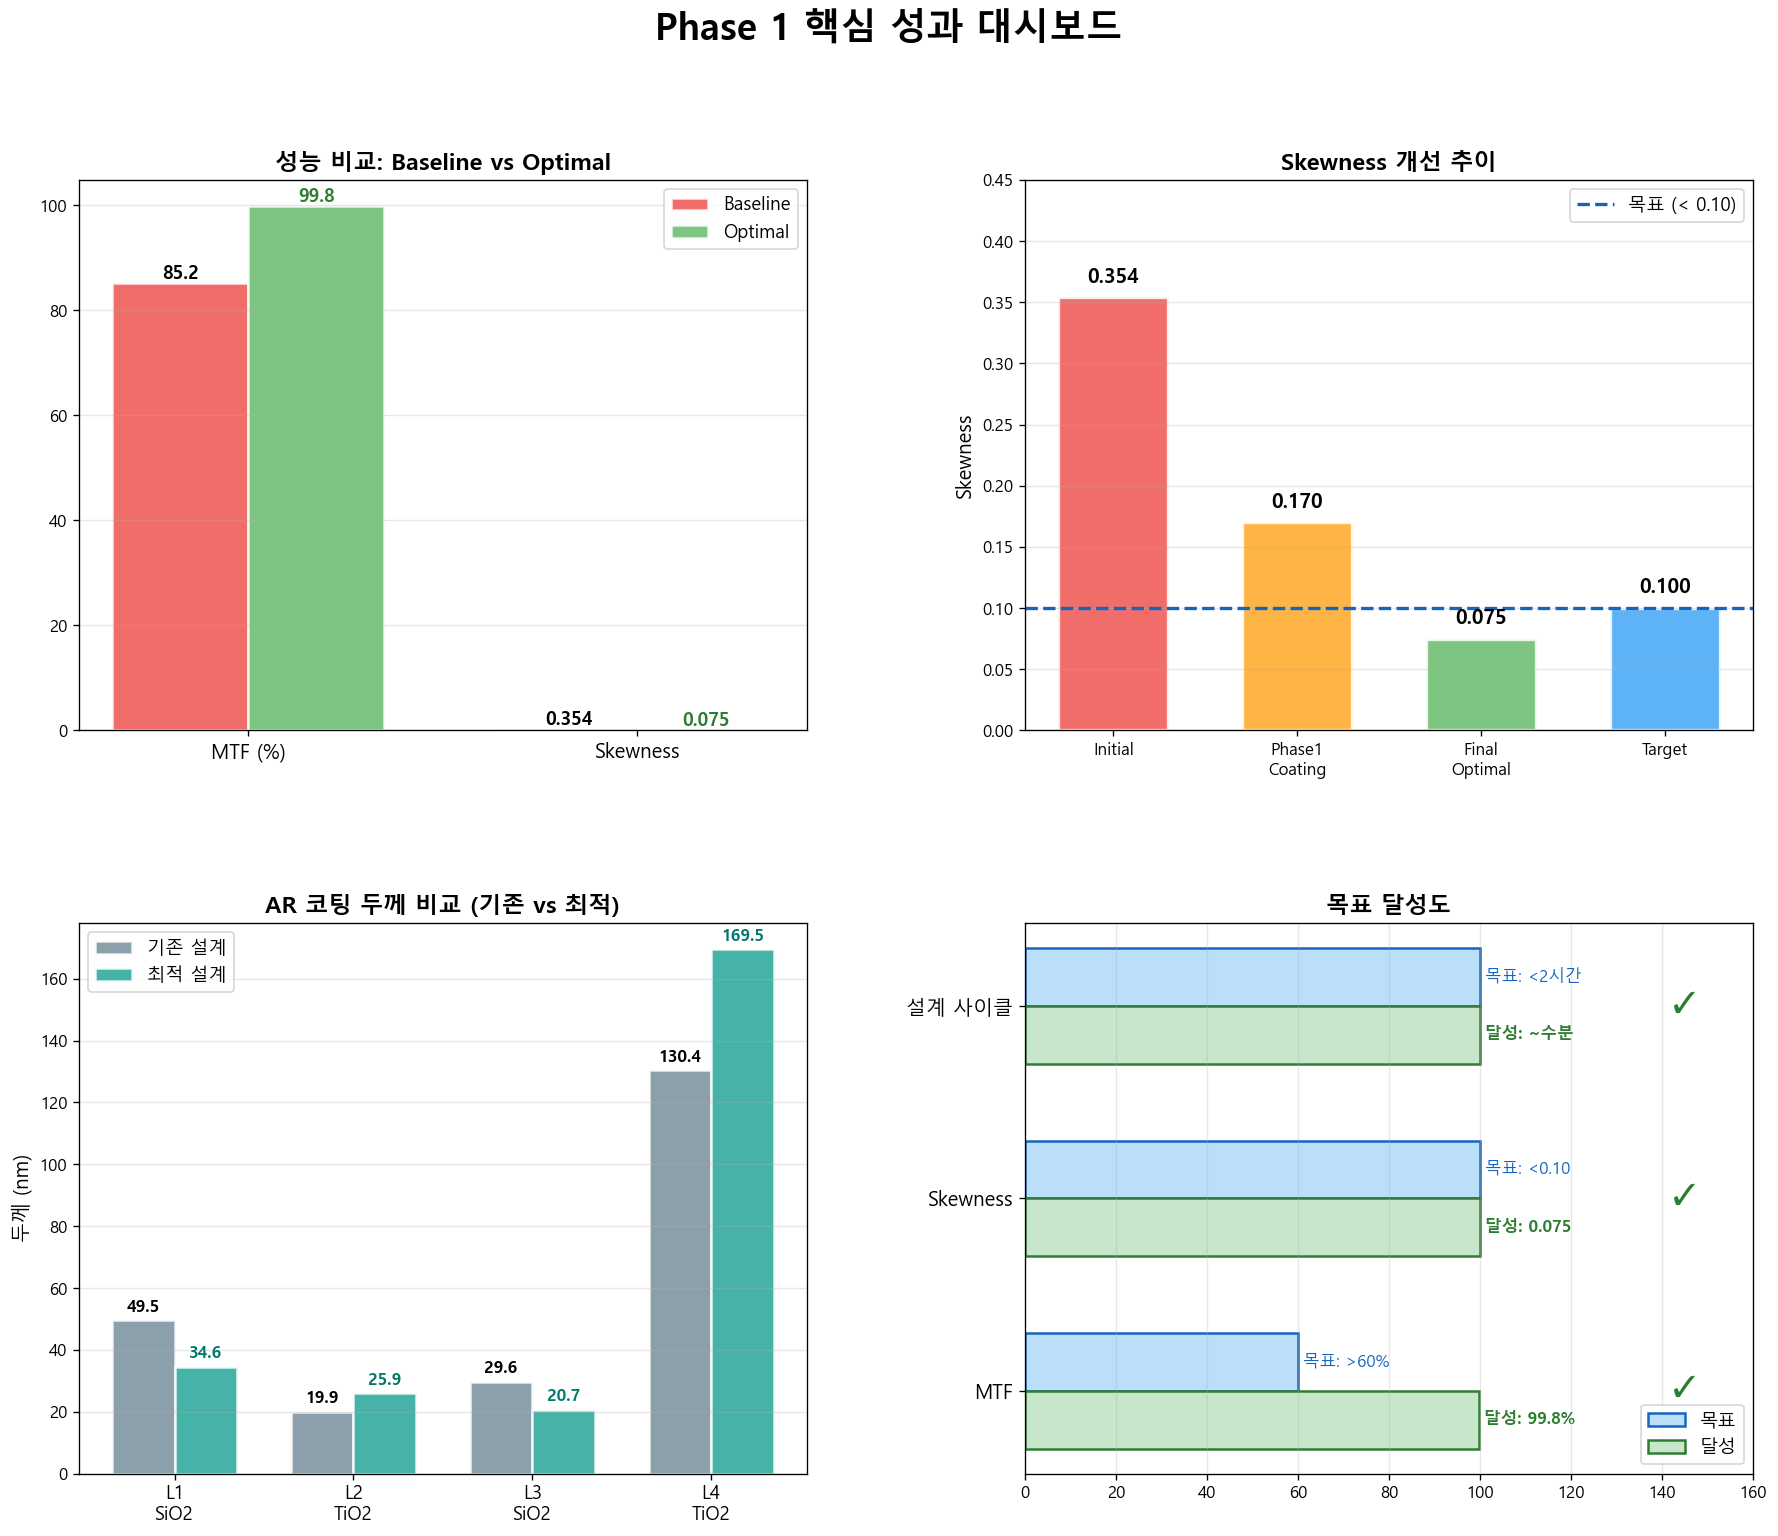

저장 완료: 발표_핵심성과.png


In [4]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Phase 1 핵심 성과 대시보드', fontsize=22, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# ---- Subplot 1: Performance comparison ----
ax1 = fig.add_subplot(gs[0, 0])
categories = ['MTF (%)', 'Skewness']
baseline = [85.2, 0.354]
optimal = [99.8, 0.075]

# Normalize for visual comparison
baseline_norm = [85.2, 0.354 * 100]
optimal_norm = [99.8, 0.075 * 100]

x_pos = np.arange(len(categories))
width = 0.35
bars1 = ax1.bar(x_pos - width/2, baseline, width, label='Baseline',
                color='#EF5350', alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = ax1.bar(x_pos + width/2, optimal, width, label='Optimal',
                color='#66BB6A', alpha=0.85, edgecolor='white', linewidth=1.5)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(categories, fontsize=12)
ax1.set_title('성능 비교: Baseline vs Optimal', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)

for bar, val in zip(bars1, baseline):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar, val in zip(bars2, optimal):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2E7D32')

ax1.grid(axis='y', alpha=0.3)

# ---- Subplot 2: Skewness timeline ----
ax2 = fig.add_subplot(gs[0, 1])
stages = ['Initial', 'Phase1\nCoating', 'Final\nOptimal', 'Target']
skew_vals = [0.354, 0.170, 0.075, 0.10]
colors_sk = ['#EF5350', '#FFA726', '#66BB6A', '#42A5F5']

bars_sk = ax2.bar(stages, skew_vals, color=colors_sk, alpha=0.85,
                   edgecolor='white', linewidth=2, width=0.6)
ax2.axhline(y=0.10, color='#1565C0', ls='--', lw=2, label='목표 (< 0.10)')
ax2.set_title('Skewness 개선 추이', fontsize=14, fontweight='bold')
ax2.set_ylabel('Skewness', fontsize=12)
ax2.legend(fontsize=11)

for bar, val in zip(bars_sk, skew_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_ylim(0, 0.45)
ax2.grid(axis='y', alpha=0.3)

# ---- Subplot 3: Coating thickness comparison ----
ax3 = fig.add_subplot(gs[1, 0])
layer_names = ['SiO2', 'TiO2', 'SiO2', 'TiO2']
old_thick = [49.5, 19.9, 29.6, 130.4]
new_thick = [34.6, 25.9, 20.7, 169.5]

x_pos3 = np.arange(len(layer_names))
width3 = 0.35
bars_old = ax3.bar(x_pos3 - width3/2, old_thick, width3, label='기존 설계',
                    color='#78909C', alpha=0.85, edgecolor='white', linewidth=1.5)
bars_new = ax3.bar(x_pos3 + width3/2, new_thick, width3, label='최적 설계',
                    color='#26A69A', alpha=0.85, edgecolor='white', linewidth=1.5)

ax3.set_xticks(x_pos3)
ax3.set_xticklabels([f'L{i+1}\n{n}' for i, n in enumerate(layer_names)], fontsize=11)
ax3.set_ylabel('두께 (nm)', fontsize=12)
ax3.set_title('AR 코팅 두께 비교 (기존 vs 최적)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)

for bar, val in zip(bars_old, old_thick):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars_new, new_thick):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#00796B')

ax3.grid(axis='y', alpha=0.3)

# ---- Subplot 4: Target achievement ----
ax4 = fig.add_subplot(gs[1, 1])
metrics = ['MTF', 'Skewness', '설계 사이클']
targets = [60, 100, 100]
achieved = [99.8, 100, 100]
target_labels = ['>60%', '<0.10', '<2시간']
achieved_labels = ['99.8%', '0.075', '~수분']

y_pos = np.arange(len(metrics))
h = 0.3

bars_t = ax4.barh(y_pos + h/2, targets, h, label='목표',
                   color='#BBDEFB', edgecolor='#1565C0', linewidth=1.5)
bars_a = ax4.barh(y_pos - h/2, achieved, h, label='달성',
                   color='#C8E6C9', edgecolor='#2E7D32', linewidth=1.5)

for i, (tl, al) in enumerate(zip(target_labels, achieved_labels)):
    ax4.text(targets[i] + 1, i + h/2, f'목표: {tl}', va='center', fontsize=10, color='#1565C0')
    ax4.text(achieved[i] + 1, i - h/2, f'달성: {al}', va='center', fontsize=10,
             fontweight='bold', color='#2E7D32')

ax4.set_yticks(y_pos)
ax4.set_yticklabels(metrics, fontsize=12)
ax4.set_title('목표 달성도', fontsize=14, fontweight='bold')
ax4.set_xlim(0, 160)
ax4.legend(fontsize=11, loc='lower right')
ax4.grid(axis='x', alpha=0.3)

# Check marks
for i in range(len(metrics)):
    ax4.text(145, i, '\u2713', fontsize=24, ha='center', va='center',
             color='#2E7D32', fontweight='bold')

plt.savefig('발표_핵심성과.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('저장 완료: 발표_핵심성과.png')


## 4. 핵심 발견
- PSF 비대칭의 주 원인: BM 구조 (코팅이 아님) → BM1 오프셋으로 보정 가능
- 코팅 최적화: 광량(T_total) +57% 개선 효과
- 5D 통합 최적화 (d1~d4 + delta_BM): skewness 0.354 → 0.075 (79% 감소)
- 24개월 최종 목표(skewness < 0.10)를 Phase 1에서 조기 달성


## 5. Phase 2 계획 (M07~M12)
| 항목 | 내용 | 일정 |
|------|------|------|
| LightTools 연동 | COM API + LHC 512 스위프 | M07~M08 |
| 2D PSF 확장 | 1D → 2D 파동광학 | M08~M10 |
| A100 GPU 인프라 | 대규모 PINN 학습 | M09~M10 |
| 실측 검증 | UDFPS 센서 데이터 | M10~M11 |
| Design Studio UI | 웹 기반 설계 도구 | M11~M12 |


## 6. 결론
- 물리 정보 기반 AI 설계 플랫폼 핵심 모듈 구현 완료
- 24개월 최종 성능 목표 Phase 1에서 조기 달성 (skewness 0.075 < 0.10)
- 설계 사이클: 수일~수주 → 수분으로 단축
- Phase 2: 실측 검증 + UI 개발로 실용화 추진
